## imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

import tidy3d as td
from tidy3d.constants import C_0
from tidy3d.plugins.mode import ModeSolver

## folders

In [20]:
root = Path.cwd().parents[1]

data_root = root / "waveguide_design" / "data" / "raw"

run_name = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = data_root / f"width_sweep_{run_name}"

plot_dir = run_dir / "plots"
field_dir = run_dir / "fields"
csv_dir = run_dir / "csv"

for d in [run_dir, plot_dir, field_dir, csv_dir]:
    d.mkdir(parents=True, exist_ok=True)

print("Run directory:", run_dir)

Run directory: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\width_sweep_20260502_005347


## settings

In [21]:
settings = {
    "lambda_min_nm": 1500,
    "lambda_max_nm": 1600,
    "lambda0_um": 1.55,

    "wg_thickness_um": 0.350,

    # Width sweep
    "width_start_um": 0.4,
    "width_stop_um": 2.4,
    "width_num_points": 20,

    # Simulation domain
    "x_span_um": 10.0,
    "y_span_um": 10.0,
    "z_span_um": 0.5,

    # Grid
    "use_auto_grid": True,
    "min_steps_per_wvl": 20,

    # Mesh override
    "use_mesh_override": True,
    "mesh_override_x_extra_um": 2.0,
    "mesh_override_y_span_um": 2.0,
    "mesh_override_z_span_um": 0.5,
    "mesh_override_dl_x_um": 0.01,
    "mesh_override_dl_y_um": 0.01,
    "mesh_override_dl_z_um": 0.05,

    # Used only if use_auto_grid = False
    "uniform_grid_um": 0.1,

    # PML
    "use_custom_pml_layers": True,
    "pml_num_layers": 12,

    # Modes
    "num_modes": 8,

    # Plotting
    "x_plot_min_um": -2.5,
    "x_plot_max_um":  2.5,
    "y_plot_min_um": -1.5,
    "y_plot_max_um":  1.5,
    "cmap_name": "jet",
}

## width array

In [22]:
widths_um = np.linspace(
    settings["width_start_um"],
    settings["width_stop_um"],
    settings["width_num_points"],
)

widths_um

array([0.4       , 0.50526316, 0.61052632, 0.71578947, 0.82105263,
       0.92631579, 1.03157895, 1.13684211, 1.24210526, 1.34736842,
       1.45263158, 1.55789474, 1.66315789, 1.76842105, 1.87368421,
       1.97894737, 2.08421053, 2.18947368, 2.29473684, 2.4       ])

## Material Dispersion Models

We use analytic refractive index models for silicon nitride and silicon dioxide.

### Silicon Nitride

$$
n_{\mathrm{SiN}}^2(\lambda)
=
1
+
\frac{B_1 \lambda^2}{\lambda^2 - C_1^2}
-
D\lambda^2
$$

where

$$
B_1 = 2.938,
\qquad
C_1 = 0.13372,
\qquad
D = 0.02573
$$

and $\lambda$ is in $\mu\mathrm{m}$.

### Silicon Dioxide

$$
n_{\mathrm{SiO_2}}^2(\lambda)
=
1
+
\frac{B_1 \lambda^2}{10^6\lambda^2 - C_1^2}
$$

where

$$
B_1 = 1.09877 \times 10^6,
\qquad
C_1 = 92.439
$$

### Derived quantities

$$
\epsilon(\lambda) = n^2(\lambda)
$$

$$
n_g(\lambda)
=
n(\lambda)
-
\lambda
\frac{dn}{d\lambda}
$$

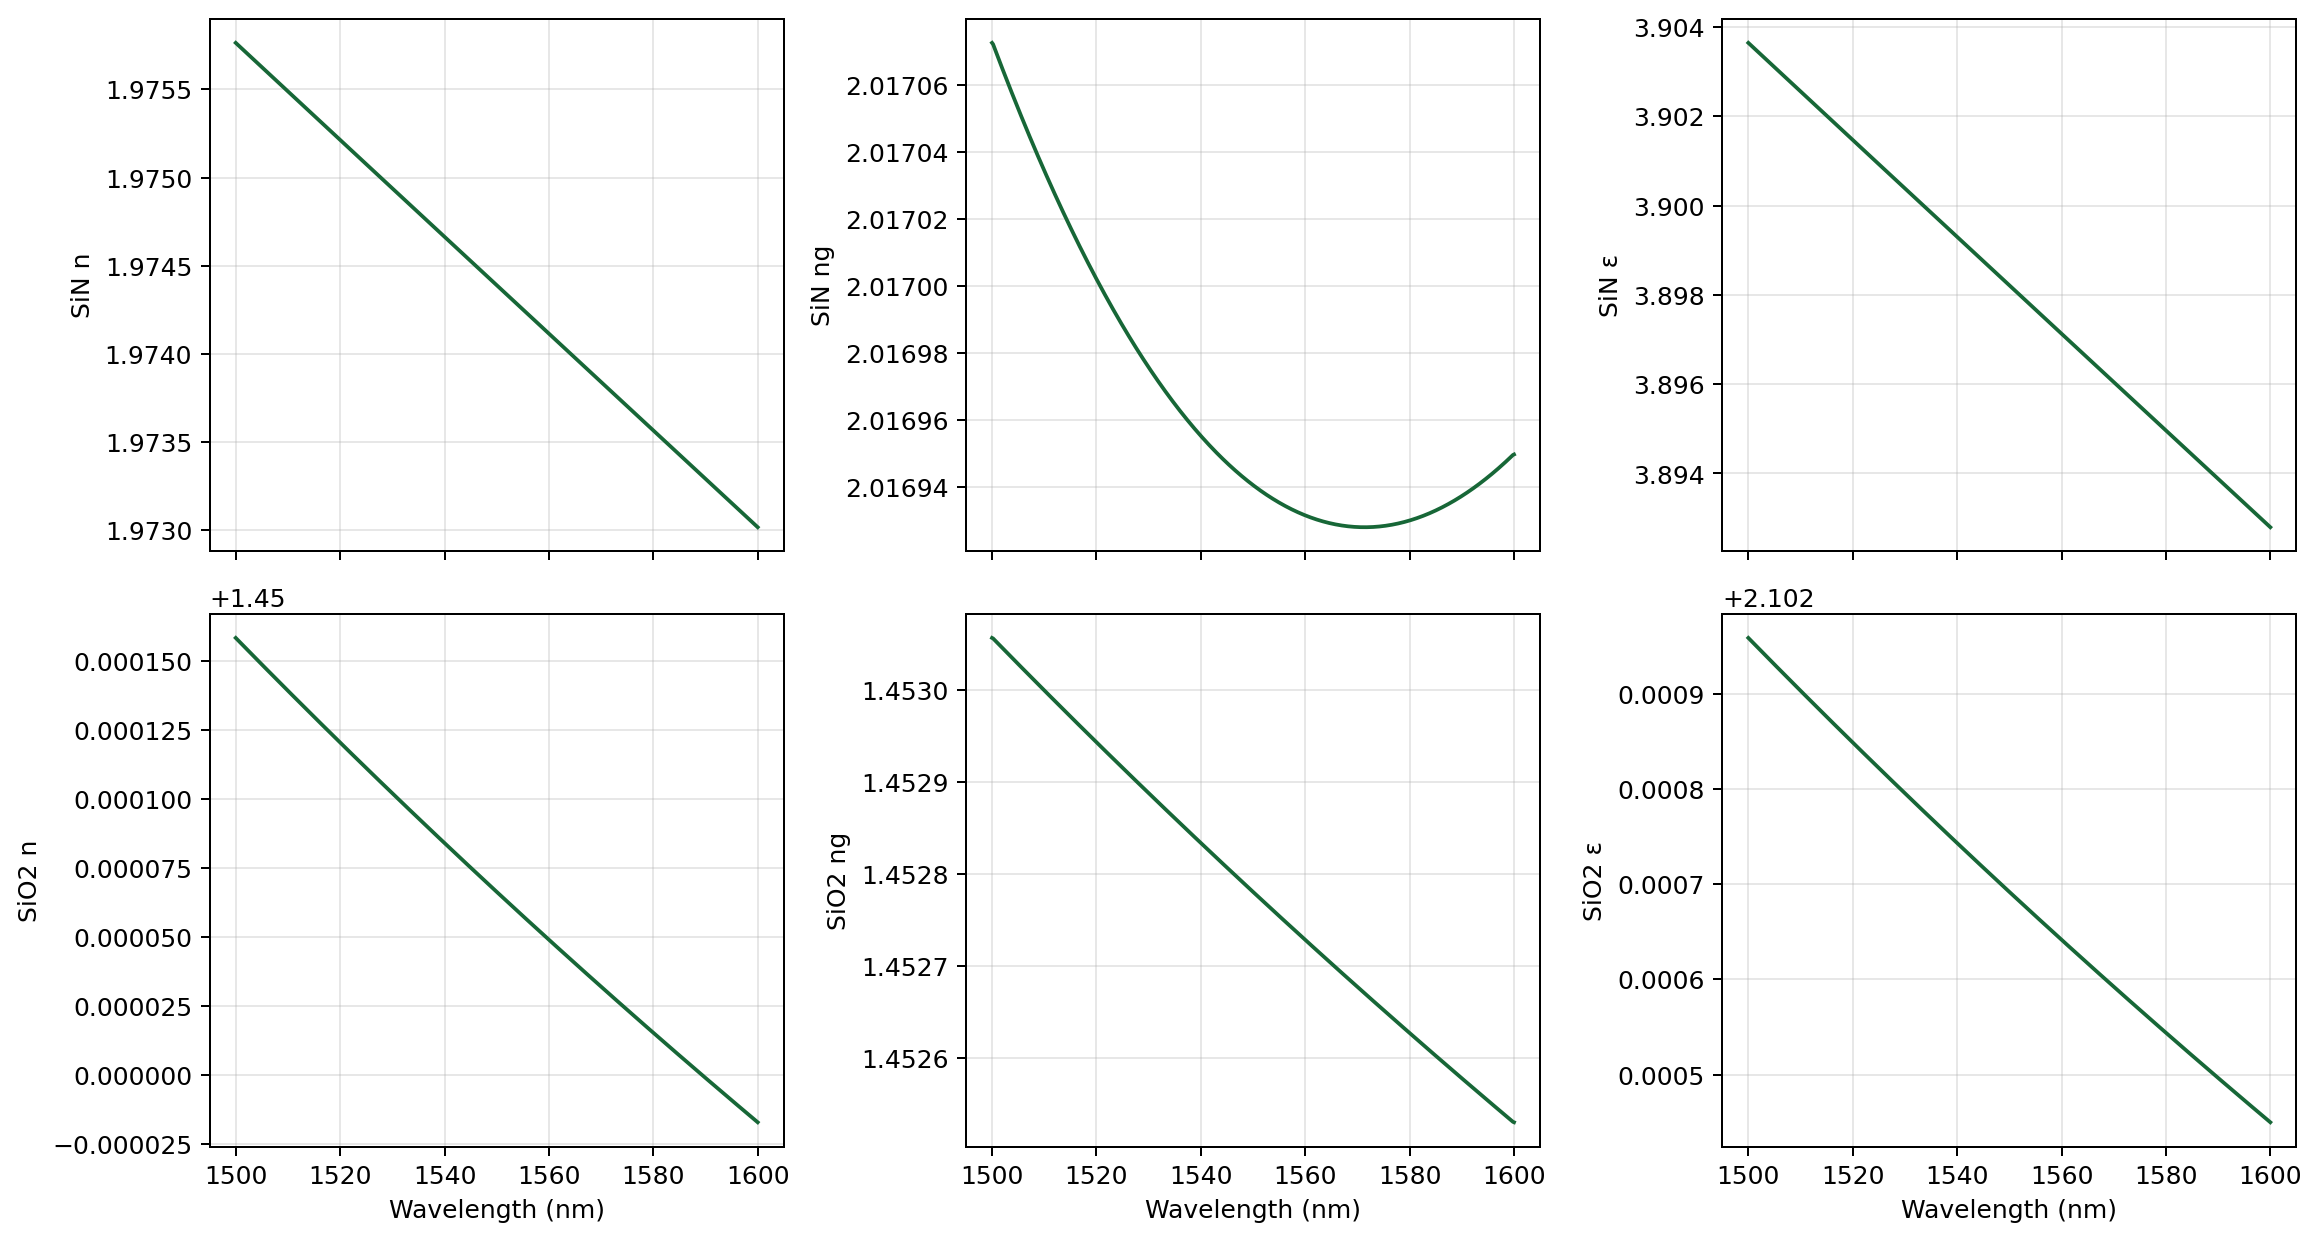

In [23]:
def n_sin(lambda_um):
    B1 = 2.938
    C1 = 0.13372
    D = 0.02573

    lam2 = lambda_um**2
    return np.sqrt(1 + (B1 * lam2) / (lam2 - C1**2) - D * lam2)


def n_sio2(lambda_um):
    B1 = 1.09877e6
    C1 = 92.439

    lam2 = lambda_um**2
    return np.sqrt(1 + (B1 * lam2) / (1e6 * lam2 - C1**2))

## plot material dispersion

lambda_nm_dense = np.linspace(
    settings["lambda_min_nm"],
    settings["lambda_max_nm"],
    501,
)

lambda_um_dense = lambda_nm_dense / 1000


def compute_material_curves(n_func):
    n = n_func(lambda_um_dense)
    dn_dlambda = np.gradient(n, lambda_nm_dense)
    ng = n - lambda_nm_dense * dn_dlambda
    eps = n**2
    return n, ng, eps


sin_n, sin_ng, sin_eps = compute_material_curves(n_sin)
sio2_n, sio2_ng, sio2_eps = compute_material_curves(n_sio2)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=180, sharex=True)

axes[0, 0].plot(lambda_nm_dense, sin_n)
axes[0, 0].set_ylabel("SiN n")

axes[0, 1].plot(lambda_nm_dense, sin_ng)
axes[0, 1].set_ylabel("SiN ng")

axes[0, 2].plot(lambda_nm_dense, sin_eps)
axes[0, 2].set_ylabel("SiN ε")

axes[1, 0].plot(lambda_nm_dense, sio2_n)
axes[1, 0].set_ylabel("SiO2 n")

axes[1, 1].plot(lambda_nm_dense, sio2_ng)
axes[1, 1].set_ylabel("SiO2 ng")

axes[1, 2].plot(lambda_nm_dense, sio2_eps)
axes[1, 2].set_ylabel("SiO2 ε")

for ax in axes[-1, :]:
    ax.set_xlabel("Wavelength (nm)")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(plot_dir / "materials.png", bbox_inches="tight")
plt.show()

## material at simulation wavelength

In [24]:
lambda0_um = settings["lambda0_um"]
freq0 = C_0 / lambda0_um

n_core = float(n_sin(lambda0_um))
n_clad = float(n_sio2(lambda0_um))

eps_core = n_core**2
eps_clad = n_clad**2

core_medium = td.Medium(permittivity=eps_core)
clad_medium = td.Medium(permittivity=eps_clad)

print("n_core:", n_core)
print("n_clad:", n_clad)
print("eps_core:", eps_core)
print("eps_clad:", eps_clad)

n_core: 1.9743895853852584
n_clad: 1.450066185745872
eps_core: 3.8982142348777726
eps_clad: 2.102691943043582


## helper functions

In [25]:
def get_field(mode_data, name, i):
    return np.squeeze(
        getattr(mode_data, name).isel(mode_index=i, f=0).values
    )


def get_xy(mode_data):
    x = np.array(mode_data.Ex.coords["x"])
    y = np.array(mode_data.Ex.coords["y"])
    return x, y


def compute_metrics(mode_data, i):
    x, y = get_xy(mode_data)
    X, Y = np.meshgrid(x, y, indexing="ij")

    Ex = get_field(mode_data, "Ex", i)
    Ey = get_field(mode_data, "Ey", i)
    Ez = get_field(mode_data, "Ez", i)

    I = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2

    dx = np.mean(np.diff(x))
    dy = np.mean(np.diff(y))
    dA = dx * dy

    P = np.sum(I) * dA

    xbar = np.sum(X * I) * dA / P
    ybar = np.sum(Y * I) * dA / P

    Aeff = P**2 / (np.sum(I**2) * dA)

    sx = np.sqrt(np.sum((X - xbar)**2 * I) * dA / P)
    sy = np.sqrt(np.sum((Y - ybar)**2 * I) * dA / P)

    mfd_x = 4 * sx
    mfd_y = 4 * sy

    TE_fraction = np.sum(np.abs(Ex)**2) / np.sum(
        np.abs(Ex)**2 + np.abs(Ey)**2
    )

    return Aeff, xbar, ybar, mfd_x, mfd_y, TE_fraction

## simulation builder

In [26]:
def build_simulation(width_um):
    wg_thick = settings["wg_thickness_um"]

    waveguide = td.Structure(
        geometry=td.Box(
            center=(0, 0, 0),
            size=(width_um, wg_thick, td.inf),
        ),
        medium=core_medium,
    )

    if settings["use_auto_grid"]:
        if settings["use_mesh_override"]:

            mesh_override_x_span_um = width_um + 2 * settings["mesh_override_x_extra_um"]

            grid_spec = td.GridSpec.auto(
                wavelength=lambda0_um,
                min_steps_per_wvl=settings["min_steps_per_wvl"],
                override_structures=[
                    td.MeshOverrideStructure(
                        geometry=td.Box(
                            center=(0, 0, 0),
                            size=(
                                mesh_override_x_span_um,
                                settings["mesh_override_y_span_um"],
                                settings["mesh_override_z_span_um"],
                            ),
                        ),
                        dl=(
                            settings["mesh_override_dl_x_um"],
                            settings["mesh_override_dl_y_um"],
                            settings["mesh_override_dl_z_um"],
                        ),
                    )
                ],
            )
        else:
            grid_spec = td.GridSpec.auto(
                wavelength=lambda0_um,
                min_steps_per_wvl=settings["min_steps_per_wvl"],
            )
    else:
        grid_spec = td.GridSpec.uniform(
            dl=settings["uniform_grid_um"],
        )

    if settings["use_custom_pml_layers"]:
        boundary = td.PML(num_layers=settings["pml_num_layers"])
    else:
        boundary = td.PML()

    sim = td.Simulation(
        size=(
            settings["x_span_um"],
            settings["y_span_um"],
            settings["z_span_um"],
        ),
        grid_spec=grid_spec,
        structures=[waveguide],
        medium=clad_medium,
        boundary_spec=td.BoundarySpec.all_sides(boundary=boundary),
        run_time=1e-12,
    )

    plane = td.Box(
        center=(0, 0, 0),
        size=(
            settings["x_span_um"],
            settings["y_span_um"],
            0,
        ),
    )

    return sim, plane

## mode solver function

In [27]:
def solve_modes_for_width(width_um):
    sim, plane = build_simulation(width_um)

    mode_spec = td.ModeSpec(
        num_modes=settings["num_modes"],
        target_neff=n_core,
        group_index_step=True,
    )

    mode_solver = ModeSolver(
        simulation=sim,
        plane=plane,
        mode_spec=mode_spec,
        freqs=[freq0],
    )

    mode_data = mode_solver.solve()

    neff_all = np.real(np.squeeze(mode_data.n_eff.values))

    if hasattr(mode_data, "n_group"):
        ng_all = np.real(np.squeeze(mode_data.n_group.values))
    else:
        ng_all = np.full_like(neff_all, np.nan, dtype=float)

    guided_mode_indices = [
        i for i, neff in enumerate(neff_all)
        if neff > n_clad
    ]

    return sim, mode_data, neff_all, ng_all, guided_mode_indices

## plotting functions

In [28]:
def plot_cross_section(sim, width_um, width_plot_dir):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=160)
    sim.plot(z=0, ax=ax)
    ax.set_title(f"Waveguide cross-section | width = {width_um:.3f} µm")

    save_path = width_plot_dir / f"width_{width_um:.3f}um_cross_section.png"
    fig.savefig(save_path, bbox_inches="tight")
    plt.close(fig)


def plot_fields_for_guided_modes(mode_data, neff_all, guided_mode_indices, width_um, width_plot_dir):
    x_plot_min_um = settings["x_plot_min_um"]
    x_plot_max_um = settings["x_plot_max_um"]
    y_plot_min_um = settings["y_plot_min_um"]
    y_plot_max_um = settings["y_plot_max_um"]
    cmap_name = settings["cmap_name"]

    x, y = get_xy(mode_data)

    field_names = [
        ["Ex", "Ey", "Ez"],
        ["Hx", "Hy", "Hz"],
    ]

    for mode_i in guided_mode_indices:

        _, _, _, _, _, TE_frac = compute_metrics(mode_data, mode_i)

        fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=180)

        for r in range(2):
            for c in range(3):
                field_name = field_names[r][c]
                data = np.real(get_field(mode_data, field_name, mode_i))

                vmax = np.nanmax(np.abs(data))
                vmin = -vmax

                im = axes[r, c].pcolormesh(
                    x,
                    y,
                    data.T,
                    shading="auto",
                    cmap=cmap_name,
                    vmin=vmin,
                    vmax=vmax,
                )

                axes[r, c].set_title(
                    f"Mode {mode_i} | Re({field_name})\n"
                    f"n_eff={neff_all[mode_i]:.6f}, TE={TE_frac:.3f}"
                )

                axes[r, c].set_xlabel("x (µm)")
                axes[r, c].set_ylabel("y (µm)")
                axes[r, c].set_xlim(x_plot_min_um, x_plot_max_um)
                axes[r, c].set_ylim(y_plot_min_um, y_plot_max_um)
                axes[r, c].set_aspect("equal")

                fig.colorbar(im, ax=axes[r, c])

        fig.suptitle(
            f"Width = {width_um:.3f} µm | Mode {mode_i} fields | "
            f"λ = {lambda0_um:.3f} µm",
            fontsize=14,
        )

        fig.tight_layout()

        save_path = width_plot_dir / f"width_{width_um:.3f}um_mode_{mode_i:02d}_fields.png"
        fig.savefig(save_path, bbox_inches="tight")
        plt.close(fig)


def plot_intensity_analysis_for_guided_modes(mode_data, neff_all, guided_mode_indices, width_um, width_plot_dir):
    x_plot_min_um = settings["x_plot_min_um"]
    x_plot_max_um = settings["x_plot_max_um"]
    y_plot_min_um = settings["y_plot_min_um"]
    y_plot_max_um = settings["y_plot_max_um"]
    cmap_name = settings["cmap_name"]

    wg_thick = settings["wg_thickness_um"]

    x, y = get_xy(mode_data)
    X, Y = np.meshgrid(x, y, indexing="ij")

    n_map = np.full_like(X, n_clad)
    n_map[(np.abs(X) <= width_um / 2) & (np.abs(Y) <= wg_thick / 2)] = n_core

    for mode_i in guided_mode_indices:

        Ex = get_field(mode_data, "Ex", mode_i)
        Ey = get_field(mode_data, "Ey", mode_i)
        Ez = get_field(mode_data, "Ez", mode_i)

        I = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
        I /= np.max(I)

        Aeff, xbar, ybar, mfdx, mfdy, TE_frac = compute_metrics(mode_data, mode_i)

        ix = np.argmin(np.abs(x - xbar))
        iy = np.argmin(np.abs(y - ybar))

        fig, ax = plt.subplots(2, 2, figsize=(11, 9), dpi=180)

        im0 = ax[0, 0].pcolormesh(
            x, y, n_map.T, shading="auto", cmap=cmap_name
        )
        ax[0, 0].set_title("Index map")
        ax[0, 0].set_xlim(x_plot_min_um, x_plot_max_um)
        ax[0, 0].set_ylim(y_plot_min_um, y_plot_max_um)
        ax[0, 0].set_aspect("equal")
        fig.colorbar(im0, ax=ax[0, 0])

        im1 = ax[0, 1].pcolormesh(
            x, y, I.T, shading="auto", cmap=cmap_name
        )

        ax[0, 1].add_patch(plt.Rectangle(
            (xbar - mfdx / 2, ybar - mfdy / 2),
            mfdx,
            mfdy,
            fill=False,
            lw=2,
            linestyle="--",
            color="white",
        ))

        ax[0, 1].set_title(
            f"|E|²\nn_eff={neff_all[mode_i]:.6f}, TE={TE_frac:.3f}"
        )
        ax[0, 1].set_xlim(x_plot_min_um, x_plot_max_um)
        ax[0, 1].set_ylim(y_plot_min_um, y_plot_max_um)
        ax[0, 1].set_aspect("equal")
        fig.colorbar(im1, ax=ax[0, 1])

        ax[1, 0].plot(x, I[:, iy])
        ax[1, 0].axvline(xbar - mfdx / 2, linestyle="--")
        ax[1, 0].axvline(xbar + mfdx / 2, linestyle="--")
        ax[1, 0].set_title(f"x cut | MFD_x = {mfdx:.3f} µm")
        ax[1, 0].set_xlim(x_plot_min_um, x_plot_max_um)
        ax[1, 0].grid(True, alpha=0.3)

        ax[1, 1].plot(y, I[ix, :])
        ax[1, 1].axvline(ybar - mfdy / 2, linestyle="--")
        ax[1, 1].axvline(ybar + mfdy / 2, linestyle="--")
        ax[1, 1].set_title(f"y cut | MFD_y = {mfdy:.3f} µm")
        ax[1, 1].set_xlim(y_plot_min_um, y_plot_max_um)
        ax[1, 1].grid(True, alpha=0.3)

        fig.suptitle(
            f"Width = {width_um:.3f} µm | Mode {mode_i} | "
            f"λ={lambda0_um:.3f} µm | "
            f"n_eff={neff_all[mode_i]:.6f} | TE={TE_frac:.3f}",
            fontsize=14,
        )

        fig.tight_layout()

        save_path = width_plot_dir / f"width_{width_um:.3f}um_mode_{mode_i:02d}_intensity_analysis.png"
        fig.savefig(save_path, bbox_inches="tight")
        plt.close(fig)

## save fields and CSV for one width

In [29]:
def save_width_outputs(mode_data, neff_all, ng_all, guided_mode_indices, width_um, width_field_dir, width_csv_dir):
    x, y = get_xy(mode_data)

    rows = []

    for mode_i in guided_mode_indices:

        fields = {}
        for name in ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]:
            fields[name] = get_field(mode_data, name, mode_i)

        np.savez(
            width_field_dir / f"width_{width_um:.3f}um_mode_{mode_i:02d}_fields.npz",
            x=x,
            y=y,
            mode_index=mode_i,
            wavelength_um=lambda0_um,
            width_um=width_um,
            thickness_um=settings["wg_thickness_um"],
            n_eff=neff_all[mode_i],
            n_g=ng_all[mode_i],
            n_clad=n_clad,
            n_core=n_core,
            **fields,
        )

        Aeff, xbar, ybar, mfdx, mfdy, te = compute_metrics(mode_data, mode_i)

        rows.append({
            "width_um": float(width_um),
            "thickness_um": float(settings["wg_thickness_um"]),
            "wavelength_um": float(lambda0_um),

            "mode": int(mode_i),
            "n_eff": float(neff_all[mode_i]),
            "n_g": float(ng_all[mode_i]),

            "mode_area_um2": float(Aeff),
            "xbar_um": float(xbar),
            "ybar_um": float(ybar),
            "mfd_x_um": float(mfdx),
            "mfd_y_um": float(mfdy),
            "TE_fraction": float(te),

            "n_core": float(n_core),
            "n_clad": float(n_clad),
        })

    df_width = pd.DataFrame(rows)

    width_csv_path = width_csv_dir / f"width_{width_um:.3f}um_guided_modes.csv"
    df_width.to_csv(width_csv_path, index=False)

    return df_width

## main sweep loop

In [30]:
# ------------------------------------------------------------
# Main width sweep loop — parallel version
# ------------------------------------------------------------

from concurrent.futures import ThreadPoolExecutor, as_completed

max_workers = 8


def run_one_width(width_um):

    print("=" * 80)
    print(f"Running width = {width_um:.3f} µm")

    width_name = f"width_{width_um:.3f}um"

    width_plot_dir = plot_dir / width_name
    width_field_dir = field_dir / width_name
    width_csv_dir = csv_dir / width_name

    for d in [width_plot_dir, width_field_dir, width_csv_dir]:
        d.mkdir(parents=True, exist_ok=True)

    sim, mode_data, neff_all, ng_all, guided_mode_indices = solve_modes_for_width(width_um)

    print(f"width = {width_um:.3f} µm")
    print("n_eff:", neff_all)
    print("Guided modes:", guided_mode_indices)

    plot_cross_section(sim, width_um, width_plot_dir)

    plot_fields_for_guided_modes(
        mode_data=mode_data,
        neff_all=neff_all,
        guided_mode_indices=guided_mode_indices,
        width_um=width_um,
        width_plot_dir=width_plot_dir,
    )

    plot_intensity_analysis_for_guided_modes(
        mode_data=mode_data,
        neff_all=neff_all,
        guided_mode_indices=guided_mode_indices,
        width_um=width_um,
        width_plot_dir=width_plot_dir,
    )

    df_width = save_width_outputs(
        mode_data=mode_data,
        neff_all=neff_all,
        ng_all=ng_all,
        guided_mode_indices=guided_mode_indices,
        width_um=width_um,
        width_field_dir=width_field_dir,
        width_csv_dir=width_csv_dir,
    )

    print(f"Done width = {width_um:.3f} µm")

    return df_width


all_width_rows = []

with ThreadPoolExecutor(max_workers=max_workers) as executor:

    futures = {
        executor.submit(run_one_width, width_um): width_um
        for width_um in widths_um
    }

    for future in as_completed(futures):

        width_um = futures[future]

        try:
            df_width = future.result()
            all_width_rows.append(df_width)

        except Exception as e:
            print("=" * 80)
            print(f"FAILED width = {width_um:.3f} µm")
            print(e)


# Sort collected results by width and mode
all_width_rows = sorted(
    all_width_rows,
    key=lambda df: df["width_um"].iloc[0]
)

print("=" * 80)
print("Sweep finished.")
print(f"Successful widths: {len(all_width_rows)} / {len(widths_um)}")

Running width = 0.400 µm
Running width = 0.505 µm
Running width = 0.611 µm
Running width = 0.716 µm
Running width = 0.821 µm
Running width = 0.926 µm
Running width = 1.032 µm
Running width = 1.137 µm


1:01:07 AM Eastern Daylight Time WARNING: Mode field at frequency index 0, mode 
                                 index 2 does not decay at the plane boundaries.

1:01:08 AM Eastern Daylight Time WARNING: Mode field at frequency index 0, mode 
                                 index 3 does not decay at the plane boundaries.

                                 WARNING: Mode field at frequency index 0, mode 
                                 index 4 does not decay at the plane boundaries.

                                 WARNING: Mode field at frequency index 0, mode 
                                 index 5 does not decay at the plane boundaries.

...

width = 2.295 µm
n_eff: [1.67010369 1.59227202 1.57672766 1.51309981 1.47576425 1.44676177
 1.44617902 1.44578304]
Guided modes: [0, 1, 2, 3, 4]
Done width = 2.295 µm


1:19:46 AM Eastern Daylight Time WARNING: Mode field at frequency index 0, mode 
                                 index 6 does not decay at the plane boundaries.

1:19:47 AM Eastern Daylight Time WARNING: Mode field at frequency index 1, mode 
                                 index 6 does not decay at the plane boundaries.

                                 WARNING: Mode field at frequency index 2, mode 
                                 index 6 does not decay at the plane boundaries.

width = 2.400 µm
n_eff: [1.67210166 1.59994963 1.57820546 1.51857266 1.48882058 1.44712245
 1.44618631 1.44582172]
Guided modes: [0, 1, 2, 3, 4]
Done width = 2.400 µm
Sweep finished.
Successful widths: 20 / 20


## combined CSV

In [31]:
df_all = pd.concat(all_width_rows, ignore_index=True)

combined_csv_path = run_dir / "all_widths_guided_modes.csv"
df_all.to_csv(combined_csv_path, index=False)

df_all

,width_um,thickness_um,wavelength_um,mode,n_eff,n_g,mode_area_um2,xbar_um,ybar_um,mfd_x_um,mfd_y_um,TE_fraction,n_core,n_clad
0,0.400000,0.35,1.55,0,1.469177,1.603790,11.898572,-0.001556,0.004041,2.356106,1.831838,0.994377,1.97439,1.450066
1,0.400000,0.35,1.55,1,1.466174,1.584208,12.860904,0.004765,-0.001566,2.348606,2.039726,0.005180,1.97439,1.450066
2,0.505263,0.35,1.55,0,1.493223,1.721447,7.633692,-0.001092,0.004499,1.827097,1.448711,0.992282,1.97439,1.450066
3,0.505263,0.35,1.55,1,1.479446,1.653668,9.463506,0.004817,-0.001877,1.916013,1.767409,0.006820,1.97439,1.450066
4,0.610526,0.35,1.55,0,1.520065,1.812893,5.918703,-0.000600,0.004701,1.586510,1.246119,0.992007,1.97439,1.450066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2.400000,0.35,1.55,0,1.672102,1.945825,5.256048,0.001694,0.004967,2.111781,0.875235,0.999574,1.97439,1.450066
62,2.400000,0.35,1.55,1,1.599950,1.991154,6.470535,0.000637,0.004892,3.172844,0.921965,0.997655,1.97439,1.450066
63,2.400000,0.35,1.55,2,1.578205,1.852057,8.928124,0.004779,-0.002434,2.271649,1.323906,0.003233,1.97439,1.450066
64,2.400000,0.35,1.55,3,1.518573,1.858270,10.190687,0.004915,-0.002616,3.527314,1.393486,0.011610,1.97439,1.450066


## save settings

In [32]:
settings_df = pd.DataFrame(
    [{"key": k, "value": v} for k, v in settings.items()]
)

settings_path = run_dir / "settings.csv"
settings_df.to_csv(settings_path, index=False)

widths_path = run_dir / "widths.csv"
pd.DataFrame({"width_um": widths_um}).to_csv(widths_path, index=False)

print("Saved combined CSV:", combined_csv_path)
print("Saved settings:", settings_path)
print("Saved widths:", widths_path)
print("Run directory:", run_dir)

Saved combined CSV: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\width_sweep_20260502_005347\all_widths_guided_modes.csv
Saved settings: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\width_sweep_20260502_005347\settings.csv
Saved widths: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\width_sweep_20260502_005347\widths.csv
Run directory: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\width_sweep_20260502_005347


## quick summary

In [33]:
print("Total guided-mode rows:", len(df_all))
print("Widths simulated:", df_all["width_um"].nunique())

df_all[
    [
        "width_um",
        "mode",
        "n_eff",
        "n_g",
        "mode_area_um2",
        "mfd_x_um",
        "mfd_y_um",
        "TE_fraction",
    ]
]

Total guided-mode rows: 66
Widths simulated: 20


,width_um,mode,n_eff,n_g,mode_area_um2,mfd_x_um,mfd_y_um,TE_fraction
0,0.400000,0,1.469177,1.603790,11.898572,2.356106,1.831838,0.994377
1,0.400000,1,1.466174,1.584208,12.860904,2.348606,2.039726,0.005180
2,0.505263,0,1.493223,1.721447,7.633692,1.827097,1.448711,0.992282
3,0.505263,1,1.479446,1.653668,9.463506,1.916013,1.767409,0.006820
4,0.610526,0,1.520065,1.812893,5.918703,1.586510,1.246119,0.992007
...,...,...,...,...,...,...,...,...
61,2.400000,0,1.672102,1.945825,5.256048,2.111781,0.875235,0.999574
62,2.400000,1,1.599950,1.991154,6.470535,3.172844,0.921965,0.997655
63,2.400000,2,1.578205,1.852057,8.928124,2.271649,1.323906,0.003233
64,2.400000,3,1.518573,1.858270,10.190687,3.527314,1.393486,0.011610
